# DataFrame Query, Merge

In [1]:
import warnings
warnings.filterwarnings(action='ignore')

import pandas as pd
import numpy as np

In [3]:
# Titanic 데이터셋 로드
titanic_df = pd.read_csv('data/titanic/train.csv')
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Query를 이용한 데이터 조회
 - query(): 조건식을 문자열 형식으로 작성하여 조회

In [4]:
# exam.csv 데이터 로드
exam_df = pd.read_csv('data/exam.csv')
exam_df.head()

,id,nclass,math,english,science
0,1,1,50,98,50
1,2,1,60,97,60
2,3,1,45,86,78
3,4,1,30,98,58
4,5,2,25,80,65


In [6]:
# exam_df의 형태, 정보 확인
exam_df.shape
exam_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   id       20 non-null     int64
 1   nclass   20 non-null     int64
 2   math     20 non-null     int64
 3   english  20 non-null     int64
 4   science  20 non-null     int64
dtypes: int64(5)
memory usage: 932.0 bytes


In [15]:
# 수학 점수가 70점 이상인 2반 학생들 데이터 조회
# 두 개 이상의 조건은 And(&), OR(|) 연산 적용
# math >= 70 & nclass == 2
# exam_df.query('math >= 70 and nclass == 2')
exam_df.query('math >= 70 & nclass == 2')

,id,nclass,math,english,science
6,7,2,80,90,45
7,8,2,90,78,25


In [ ]:
# 1반 이거나 또는 영어 점수가 80점 이상인 데이터 조회
# exam_df.query('english >= 80 | nclass == 1')
exam_df.query('english >= 80 or nclass == 1')

In [ ]:
# nclass 기준 groupby
exam_df.groupby('nclass')['id'].count()

# 1, 3, 5반 데이터만 조회
#exam_df.query('nclass == 1 or nclass == 3 or nclass == 5')
#exam_df.query('nclass == 1 | nclass == 3 | nclass == 5')
exam_df.query('nclass in [1, 3, 5]')

In [36]:
# 1반의 수학, 과학 점수 평균 조회
exam_df.query('nclass == 1')[['math', 'science', 'english']].mean()

math       46.25
science    61.50
english    94.75
dtype: float64

In [35]:
# 1반의 수학, 과학 점수 중앙값 조회
exam_df.query('nclass == 1')[['math', 'science', 'english']].median()

math       47.5
science    59.0
english    97.5
dtype: float64

In [41]:
# 변수를 이용하여 query 조건 생성
a = int(input('반을 입력해주세요'))
exam_df.query('nclass == @a')[['nclass','english']]

반을 입력해주세요 3


,nclass,english
8,3,98
9,3,98
10,3,65
11,3,85


In [39]:
exam_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   id       20 non-null     int64
 1   nclass   20 non-null     int64
 2   math     20 non-null     int64
 3   english  20 non-null     int64
 4   science  20 non-null     int64
dtypes: int64(5)
memory usage: 932.0 bytes


- ### 타이타닉 데이터셋 쿼리 실습

In [ ]:
titanic_df

In [ ]:
# 1등급 객실의 승객 정보 조회 - Boolean Indexing
titanic_df[titanic_df['Pclass'] == 1]

In [ ]:
# 1등급 객실의 승객 정보 조회 - query
titanic_df.query('Pclass == 1')

In [ ]:
# 생존한 여성 승객 조회
# titanic_df[(titanic_df['Survived'] == 1) & (titanic_df['Sex'] == 'female')]
titanic_df.query('Survived == 1 and Sex == "female"')

In [56]:
# S, Q 항구에서 탑승한 승객 중 생존자 조회
ports = ['S', 'Q']

# titanic_df.query('Embarked in["S", "Q"] and Survived == 1').groupby('Embarked')[['Survived']].count()
titanic_df.query('Embarked in @ports and Survived == 1').groupby('Embarked')[['Survived']].count()

,Survived
Embarked,
Q,30
S,217


In [ ]:
# query() 함수의 메서드 체이닝
# 1, 2 객실 등급의 남자 승객 조회, 나이가 20살 이상, Embarked = S
titanic_df \
    .query('Pclass in [1, 2]') \
    .query('Sex == "male"') \
    .query('Age >= 20') \
    .query('Embarked == "S"')

## 2. Merge
 - SQL의 조인과 유사함
 - inner join
 - left join
 - right join
 - full outer join 

### (1) Inner join
 - key를 기준으로 두 개의 데이터프레임(테이블)에 동일하게 존재하는 데이터를 추철
 - 예제) '이름'을 키로하여 Inner join(교집합) 수행

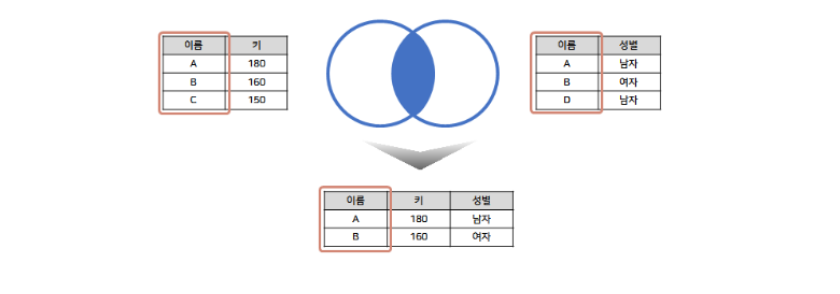

In [67]:
df1 = pd.DataFrame(
    {
        '이름': ['홍길동', '이순신', '김유신'],
        '키': [180, 170, 175]
    }
)
df1

,이름,키
0,홍길동,180
1,이순신,170
2,김유신,175


In [68]:
df2 = pd.DataFrame(
    {
        '이름' : ['홍길동', '이순신', '김영희'],
        '성별': ['남자', '남자', '여자']
    }
)
df2

,이름,성별
0,홍길동,남자
1,이순신,남자
2,김영희,여자


In [70]:
# Inner Join, how = inner 기본값, 생략 가능
pd.merge(df1, df2)

,이름,키,성별
0,홍길동,180,남자
1,이순신,170,남자


### (2) Left Outer Join
- 왼쪽 데이터셋에 있는 데이터프레임(테이블)의 키를 기준으로 병합

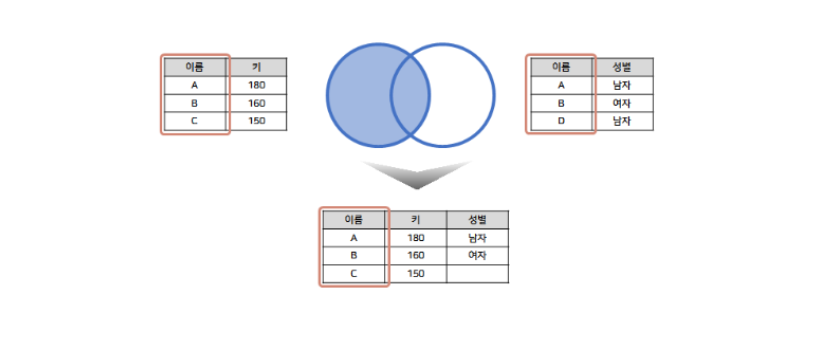

In [72]:
# df1, df2 데이터프레임 left Outer Join(Inner Join + Left 테이블 모든 데이터셋)
pd.merge(df1, df2, how = 'left')

,이름,키,성별
0,홍길동,180,남자
1,이순신,170,남자
2,김유신,175,NaN


### (3) Right Outer join
- 오른쪽 데이터프레임에 있는 모든 데이터를 병합

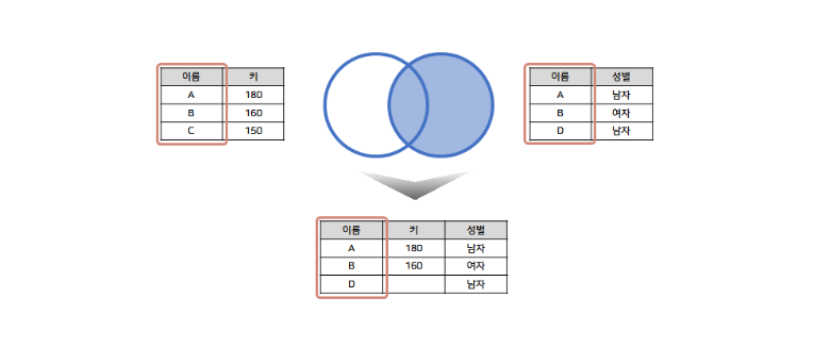

In [73]:
print(df1)
print('-'*30)
print(df2)

    이름    키
0  홍길동  180
1  이순신  170
2  김유신  175
------------------------------
    이름  성별
0  홍길동  남자
1  이순신  남자
2  김영희  여자


In [76]:
# Right Outer Join
pd.merge(df1, df2, how='right')

,이름,키,성별
0,홍길동,180.0,남자
1,이순신,170.0,남자
2,김영희,NaN,여자


### (4) Full Outer Join
- 키를 기준으로 두 데이터프레임의 존재하는 모든 데이터를 기준으로 병합

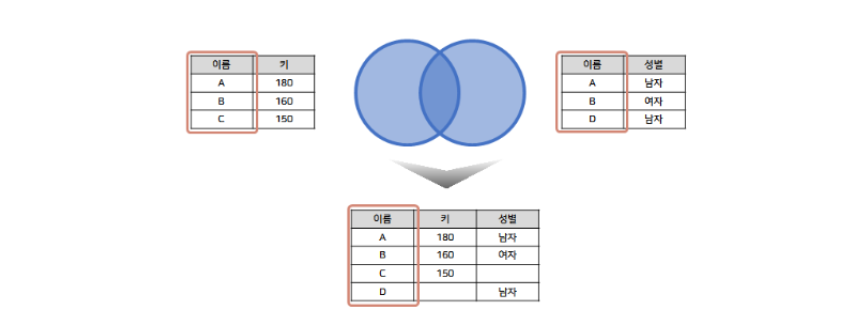

In [78]:
# Full Outer Join
pd.merge(df1, df2, how = 'outer')

,이름,키,성별
0,김영희,NaN,여자
1,김유신,175.0,NaN
2,이순신,170.0,남자
3,홍길동,180.0,남자


## 3. Concat 함수를 이용한 데이터 병합

In [81]:
df1= pd.DataFrame(
    {
        '이름' : ['홍길동', '이순신', '김유신'],
        '키' : [180, 170, 175],
        '나이' : [23, 30, 40],
        '주소' : ['서울', '부산', '원주']
    }
)
df1

,이름,키,나이,주소
0,홍길동,180,23,서울
1,이순신,170,30,부산
2,김유신,175,40,원주


In [82]:
df2= pd.DataFrame(
    {
        '이름' : ['Smith', 'Anne', 'Kelly'],
        '키' : [180, 170, 175],
        '나이' : [23, 30, 40],
        '주소' : ['미국', '캐나다', '멕시코']
    }
)
df2

,이름,키,나이,주소
0,Smith,180,23,미국
1,Anne,170,30,캐나다
2,Kelly,175,40,멕시코


In [ ]:
# df1, df2를 행 기준으로 concat
df_concat = pd.concat([df1, df2])
df_concat

In [97]:
# df_concat 데이터프레임 인덱스 재생성, 기존 인덱스 삭제, 원본 반영
df_concat.reset_index(drop=True, inplace=True)
df_concat

,이름,키,나이,주소
0,홍길동,180,23,서울
1,이순신,170,30,부산
2,김유신,175,40,원주
3,Smith,180,23,미국
4,Anne,170,30,캐나다
5,Kelly,175,40,멕시코


In [88]:
# df1, df2를 열 기준으로 concat
df_concat = pd.concat([df1, df2], axis = 1)
df_concat

,이름,키,나이,주소,이름,키,나이,주소
0,홍길동,180,23,서울,Smith,180,23,미국
1,이순신,170,30,부산,Anne,170,30,캐나다
2,김유신,175,40,원주,Kelly,175,40,멕시코


In [89]:
# df1 객체에 '직업' 컬럼 추가
df1['직업'] = '개발자'
df1

,이름,키,나이,주소,직업
0,홍길동,180,23,서울,개발자
1,이순신,170,30,부산,개발자
2,김유신,175,40,원주,개발자


In [93]:
pd.concat([df1, df2])

,이름,키,나이,주소,직업
0,홍길동,180,23,서울,개발자
1,이순신,170,30,부산,개발자
2,김유신,175,40,원주,개발자
0,Smith,180,23,미국,NaN
1,Anne,170,30,캐나다,NaN
2,Kelly,175,40,멕시코,NaN


In [95]:
df_concat = pd.concat([df1, df2], join='inner')

## 4. 파일로 저장
- to_csv(경로, 인코딩, header...)

In [100]:
df_concat
df_concat.to_csv('data/df_concat1.csv', encoding='utf-8')

In [101]:
df_concat
df_concat.to_csv('data/df_concat2.csv', encoding='utf-8', index=False)

In [103]:
df_concat
df_concat.to_csv('data/df_concat3.csv', encoding='utf-8', index=False, header=False)

In [106]:
df3 = pd.read_csv('data/df_concat3.csv', names=['이름', '키', '나이', '주소'])
df3

,이름,키,나이,주소
0,홍길동,180,23,서울
1,이순신,170,30,부산
2,김유신,175,40,원주
3,Smith,180,23,미국
4,Anne,170,30,캐나다
5,Kelly,175,40,멕시코
